#### Find E and store it in dataset


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

In [ ]:
# Ask the user to select a folder containing the data files
root = tk.Tk()
root.withdraw()  # hide the main tkinter window
folder_path = filedialog.askdirectory(title="Please select the folder containing the data files: ")



# Find list of relative paths to .txt files in all the folders and subfolders of the selected folder
txt_files = []
for root_dir, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".txt"):
            txt_files.append(os.path.relpath(os.path.join(root_dir, file), folder_path))


#remove those in Calib folder and those ending with position.txt
txt_files = [f for f in txt_files if "Calib" not in f and not f.endswith("position.txt")]

print("List of filtered .txt files:")
for f in txt_files:
    print(f)
print("\n")

# create a df to store the results
results_df = pd.DataFrame(columns=["Folder", "Name", "Header line", "X", "Y", "E[eff] (kPa)", "E[v=0.5] (kPa)"])


# read text file tracking line until you find "Time (s)" then memorize that line and call it header_line
for l in range(len(txt_files)):
    path = os.path.join(folder_path, txt_files[l])
    results_df.loc[l, "Folder"] = os.path.dirname(txt_files[l])
    # Name is until "S-" in the filename
    results_df.loc[l, "Name"] = os.path.basename(txt_files[l]).split("S-")[0]
    with open(path, 'r', encoding='latin-1', errors='replace') as f:
        for i, line in enumerate(f):
            if "Time (s)" in line:
                results_df.loc[l, "Header line"] = i
                break
            if "E[eff]" in line:
                results_df.loc[l, "E[eff] (kPa)"] = (float(line.strip().split('\t')[-1]))/1e3
            if "E[v=0.5]" in line:
                results_df.loc[l, "E[v=0.5] (kPa)"] = (float(line.strip().split('\t')[-1]))/1e3
            if i == 2:
                parts = line.strip().split('\t')
                for idx, part in enumerate(parts[:-1]):
                    if part == "X (#)":
                        results_df.loc[l, "X"] = float(parts[idx + 1])
                    elif part == "Y (#)":
                        results_df.loc[l, "Y"] = float(parts[idx + 1])

display(results_df)

List of filtered .txt files:
matrix_scan01\gelatin 10% F4 S-1 X-1 Y-1 I-1.txt
matrix_scan01\gelatin 10% F4 S-1 X-1 Y-2 I-1.txt
matrix_scan01\gelatin 10% F4 S-1 X-2 Y-1 I-1.txt
matrix_scan01\gelatin 10% F4 S-1 X-2 Y-2 I-1.txt
matrix_scan02\gelatin 10% F4 S-1 X-1 Y-1 I-1.txt




,Folder,Name,Header line,X,Y,E[eff] (kPa),E[v=0.5] (kPa)
0,matrix_scan01,gelatin 10% F4,34,1.0,1.0,12.429103,NaN
1,matrix_scan01,gelatin 10% F4,34,1.0,1.0,13.320035,NaN
2,matrix_scan01,gelatin 10% F4,34,1.0,1.0,13.162808,NaN
3,matrix_scan01,gelatin 10% F4,34,1.0,1.0,14.586578,NaN
4,matrix_scan02,gelatin 10% F4,34,1.0,1.0,21.905456,NaN


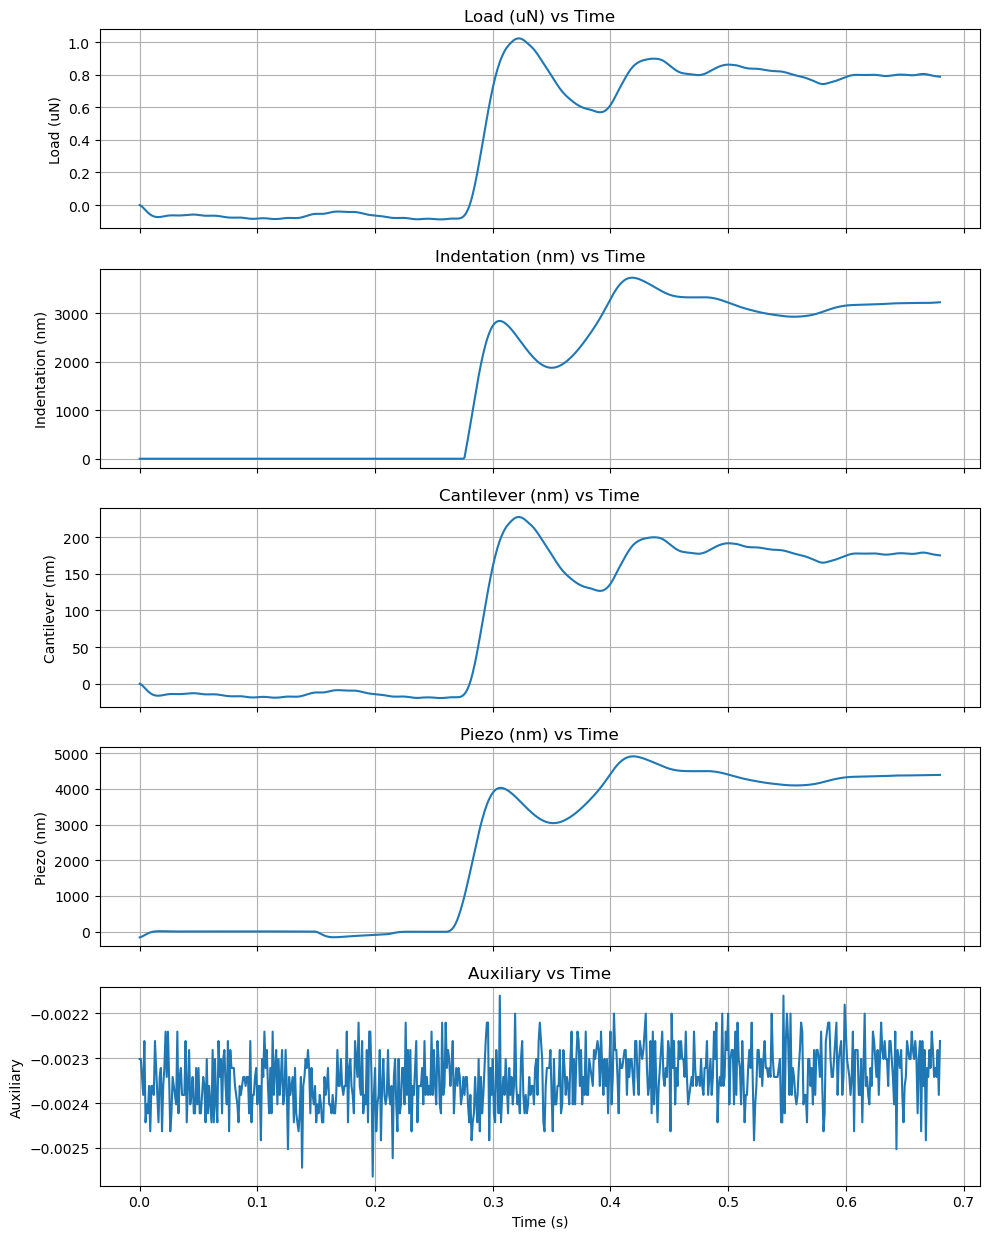

In [11]:
# Open txt file and read data into a pandas dataframe
data = pd.read_csv(path, sep='\t', header=header_line, skip_blank_lines=False, encoding='latin-1')
display(data)


time_col = "Time (s)"
cols = [c for c in data.columns if c != time_col]
n = len(cols)
fig, axs = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)
if n == 1:
    axs = [axs]
for ax, col in zip(axs, cols):
    ax.plot(data[time_col], data[col])
    ax.set_title(f"{col} vs Time")
    ax.set_ylabel(col)
    ax.grid(True)
axs[-1].set_xlabel(time_col)
plt.tight_layout()
plt.show()

        

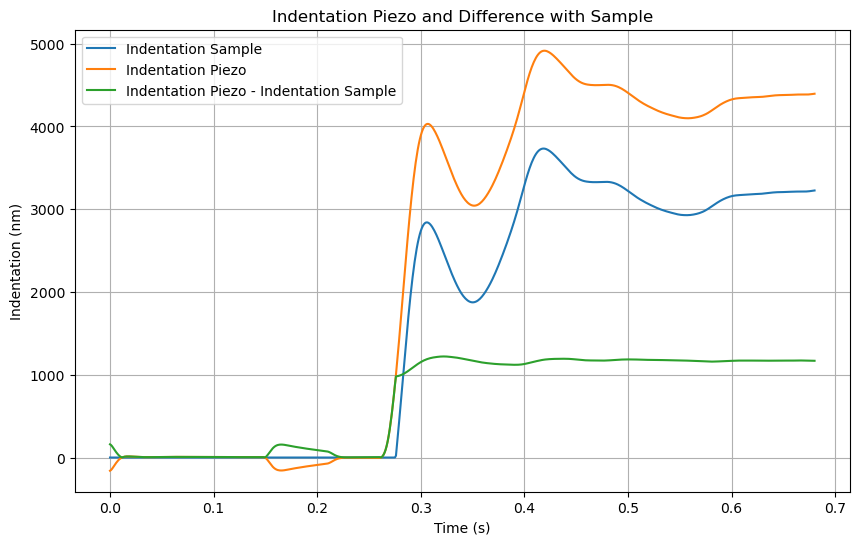

In [12]:
# plot indentation piezo and the substraction of both superimposed

plt.figure(figsize=(10, 6))
plt.plot(data[time_col], data["Indentation (nm)"], label="Indentation Sample")
plt.plot(data[time_col], data["Piezo (nm)"], label="Indentation Piezo")
plt.plot(data[time_col], abs(data["Indentation (nm)"] - data["Piezo (nm)"]), label="Indentation Piezo - Indentation Sample")
plt.title("Indentation Piezo and Difference with Sample")
plt.xlabel(time_col)
plt.ylabel("Indentation (nm)")
plt.legend()
plt.grid(True)
plt.show()


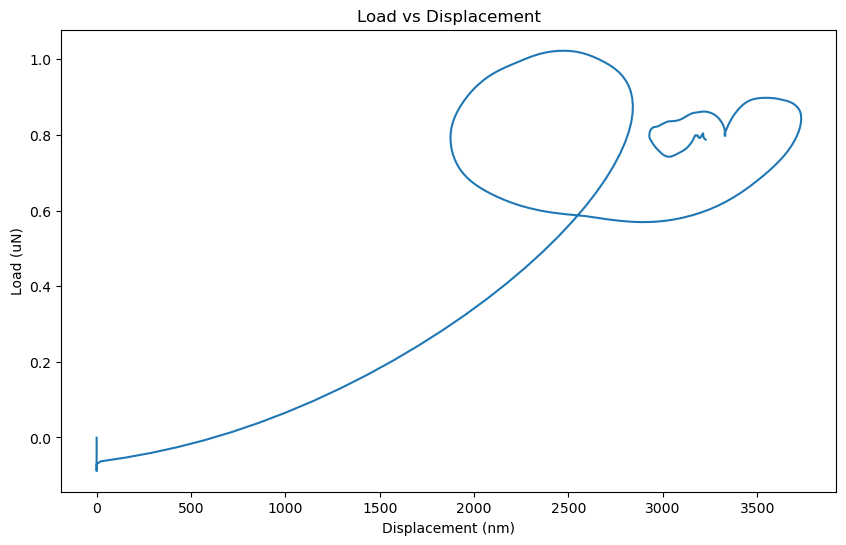

In [13]:
# plot load as a function of displacement

plt.figure(figsize=(10, 6))
plt.plot(data["Indentation (nm)"], data["Load (uN)"])
plt.title("Load vs Displacement")
plt.xlabel("Displacement (nm)")
plt.ylabel("Load (uN)")
plt.show()
